# AgroOpt — Notebook 02: Feature Engineering

**Objective**: Engineer domain-rich features from `merged_dataset.csv`, analyse their distributions and predictive signal, and persist `features_dataset.csv`.

---

## Feature Groups

| Group | Features | Description |
|---|---|---|
| Raw numeric | rainfall_mm, temperature_celsius, days_to_harvest | Original agronomic observations |
| Raw binary | fertilizer_used, irrigation_used | Management practices (0/1) |
| FAO benchmark | fao_yield_hg_ha | 2013 USA national yield per crop (hg/ha) |
| FAO anomalies | rainfall_anomaly, temp_anomaly | Local deviation from USA 2013 national average |
| Interactions | rainfall_x_fertilizer, rainfall_x_irrigation, temp_x_irrigation, agro_intensity | Synergies between inputs |
| Climate indices | heat_moisture_ratio, aridity_index, harvest_rainfall_rate | Composite climate signals |
| Crop biology | water_stress, heat_stress, gdd_proxy | Crop-specific agronomic stress + heat accumulation |
| Soil quality | soil_quality_score | Ordinal domain ranking (Sandy=1 … Loam=5) |
| One-hot | crop_*, region_*, soil_type_*, weather_condition_* | Categorical encodings |

---
## Domain Knowledge Constants — Provenance

The crop biology features (`water_stress`, `heat_stress`, `gdd_proxy`) and `soil_quality_score` are computed using established agronomic constants from the literature below.  These values are **not invented** — each can be independently verified against the cited source.

---

### 1. Optimal Annual Rainfall (mm) — `CROP_OPTIMAL_RAINFALL_MM`

Used in: `water_stress = |rainfall_mm − optimal| / optimal`

| Crop | Value (mm) | Source |
|---|---|---|
| Wheat | 500 | FAO Irrigation & Drainage Paper No. 56 (Allen et al., 1998); CIMMYT Wheat Agronomy Guidelines |
| Maize | 650 | FAO Plant Production Paper 33 — Doorenbos & Kassam (1979) |
| Soybean | 600 | USDA NRCS Agronomy Technical Note No. 1 |
| Rice | 1 200 | IRRI Rice Knowledge Bank — Water Management section |

---

### 2. Upper Thermal Limit °C — `CROP_MAX_TEMP_C`

Used in: `heat_stress = max(0, temperature_celsius − T_max)`

| Crop | Value (°C) | Source |
|---|---|---|
| Wheat | 25 | CIMMYT Wheat Physiology Manual; Wardlaw & Wrigley (1994) *Aust. J. Plant Physiol.* 21(6) |
| Maize | 32 | FAO Plant Production Paper 33; Tollenaar et al. (2004) |
| Soybean | 32 | USDA-ARS Soybean Physiology; Board & Kahlon (2011) |
| Rice | 35 | IRRI heat tolerance research; Jagadish et al. (2007) |

> **Interpretation**: a field temperature above these thresholds causes pollen sterility, accelerated grain filling, and significant yield loss.

---

### 3. Base Temperature °C — `CROP_BASE_TEMP_C`

Used in: `gdd_proxy = max(0, temperature_celsius − T_base) × days_to_harvest`

| Crop | Value (°C) | Source |
|---|---|---|
| Wheat | 0 | McMaster & Wilhelm (1997) *Agric. Forest Meteorol.* 87; USDA NRCS |
| Soybean | 6 | USDA GDD tables for soybean phenology |
| Maize | 10 | Cross & Zuber (1972) *Agron. J.*; USDA / FAO standard GDD base |
| Rice | 10 | Yin et al. (1996) *Field Crops Res.* 48; IRRI GDD reference |

> **Interpretation**: below the base temperature, the crop does not accumulate meaningful thermal units — biological development effectively stops.

---

### 4. Soil Quality Score (1–5) — `SOIL_QUALITY_SCORE`

Used in: `soil_quality_score = map(soil_type → score)`

| Score | Soil Type | Agronomic basis |
|---|---|---|
| 5 | Loam | Optimal sand/silt/clay balance — best drainage + nutrient retention |
| 4 | Silt | High fertility, excellent moisture retention, slight compaction risk |
| 3 | Clay | High CEC (nutrients retained), but poor drainage / waterlogging risk |
| 3 | Peaty | High organic matter and N, may be acidic (pH < 5.5) |
| 2 | Chalky | Alkaline (pH > 7.5), limits Fe/Mn/Zn micronutrient availability |
| 1 | Sandy | Fast-draining, low CEC, poor water and nutrient retention |

> **Sources**: FAO *Guidelines for Soil Description* (4th ed., 2006); Brady & Weil *The Nature and Properties of Soils* (15th ed.)

---

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

from src.features.feature_engineering import build_features, engineer_features
from src.utils.logging import setup_logging

setup_logging(level='WARNING')
plt.rcParams.update({'figure.figsize': (14, 5), 'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_style('whitegrid')
Path('../data/processed').mkdir(parents=True, exist_ok=True)

# Load merged dataset and apply feature engineering
merged = pd.read_csv('../data/processed/merged_dataset.csv')
feat   = build_features(merged)

TARGET = 'yield_hg_ha'
feature_cols = [c for c in feat.columns if c != TARGET]

print(f'Merged dataset  : {merged.shape}')
print(f'Feature matrix  : {feat.shape}')
print(f'Features        : {len(feature_cols)}')
print(f'Target          : {TARGET}')
print(f'Null count      : {feat.isnull().sum().sum()}')

Merged dataset  : (666494, 15)
Feature matrix  : (666494, 37)
Features        : 36
Target          : yield_hg_ha
Null count      : 0


---
## 1. Feature Summary Table

In [2]:
summary = pd.DataFrame({
    'dtype':   feat[feature_cols].dtypes,
    'unique':  feat[feature_cols].nunique(),
    'min':     feat[feature_cols].min().round(3),
    'mean':    feat[feature_cols].mean().round(3),
    'max':     feat[feature_cols].max().round(3),
    'std':     feat[feature_cols].std().round(3),
})
display(summary)

,dtype,unique,min,mean,max,std
rainfall_mm,float64,666494,100.006,550.196,999.998,259.735
temperature_celsius,float64,666494,15.000,27.501,40.000,7.218
fertilizer_used,int32,2,0.000,0.500,1.000,0.500
irrigation_used,int32,2,0.000,0.500,1.000,0.500
days_to_harvest,int64,90,60.000,104.503,149.000,25.956
fao_yield_hg_ha,int64,4,29615.000,61722.012,99256.000,31398.112
rainfall_anomaly,float64,471516,-614.994,-164.804,284.998,259.735
temp_anomaly,float64,25001,-1.440,11.061,23.560,7.218
rainfall_x_fertilizer,float64,278834,0.000,274.792,999.998,330.549
rainfall_x_irrigation,float64,278279,0.000,274.816,999.997,330.602


---
## 2. Distribution of Engineered Numeric Features

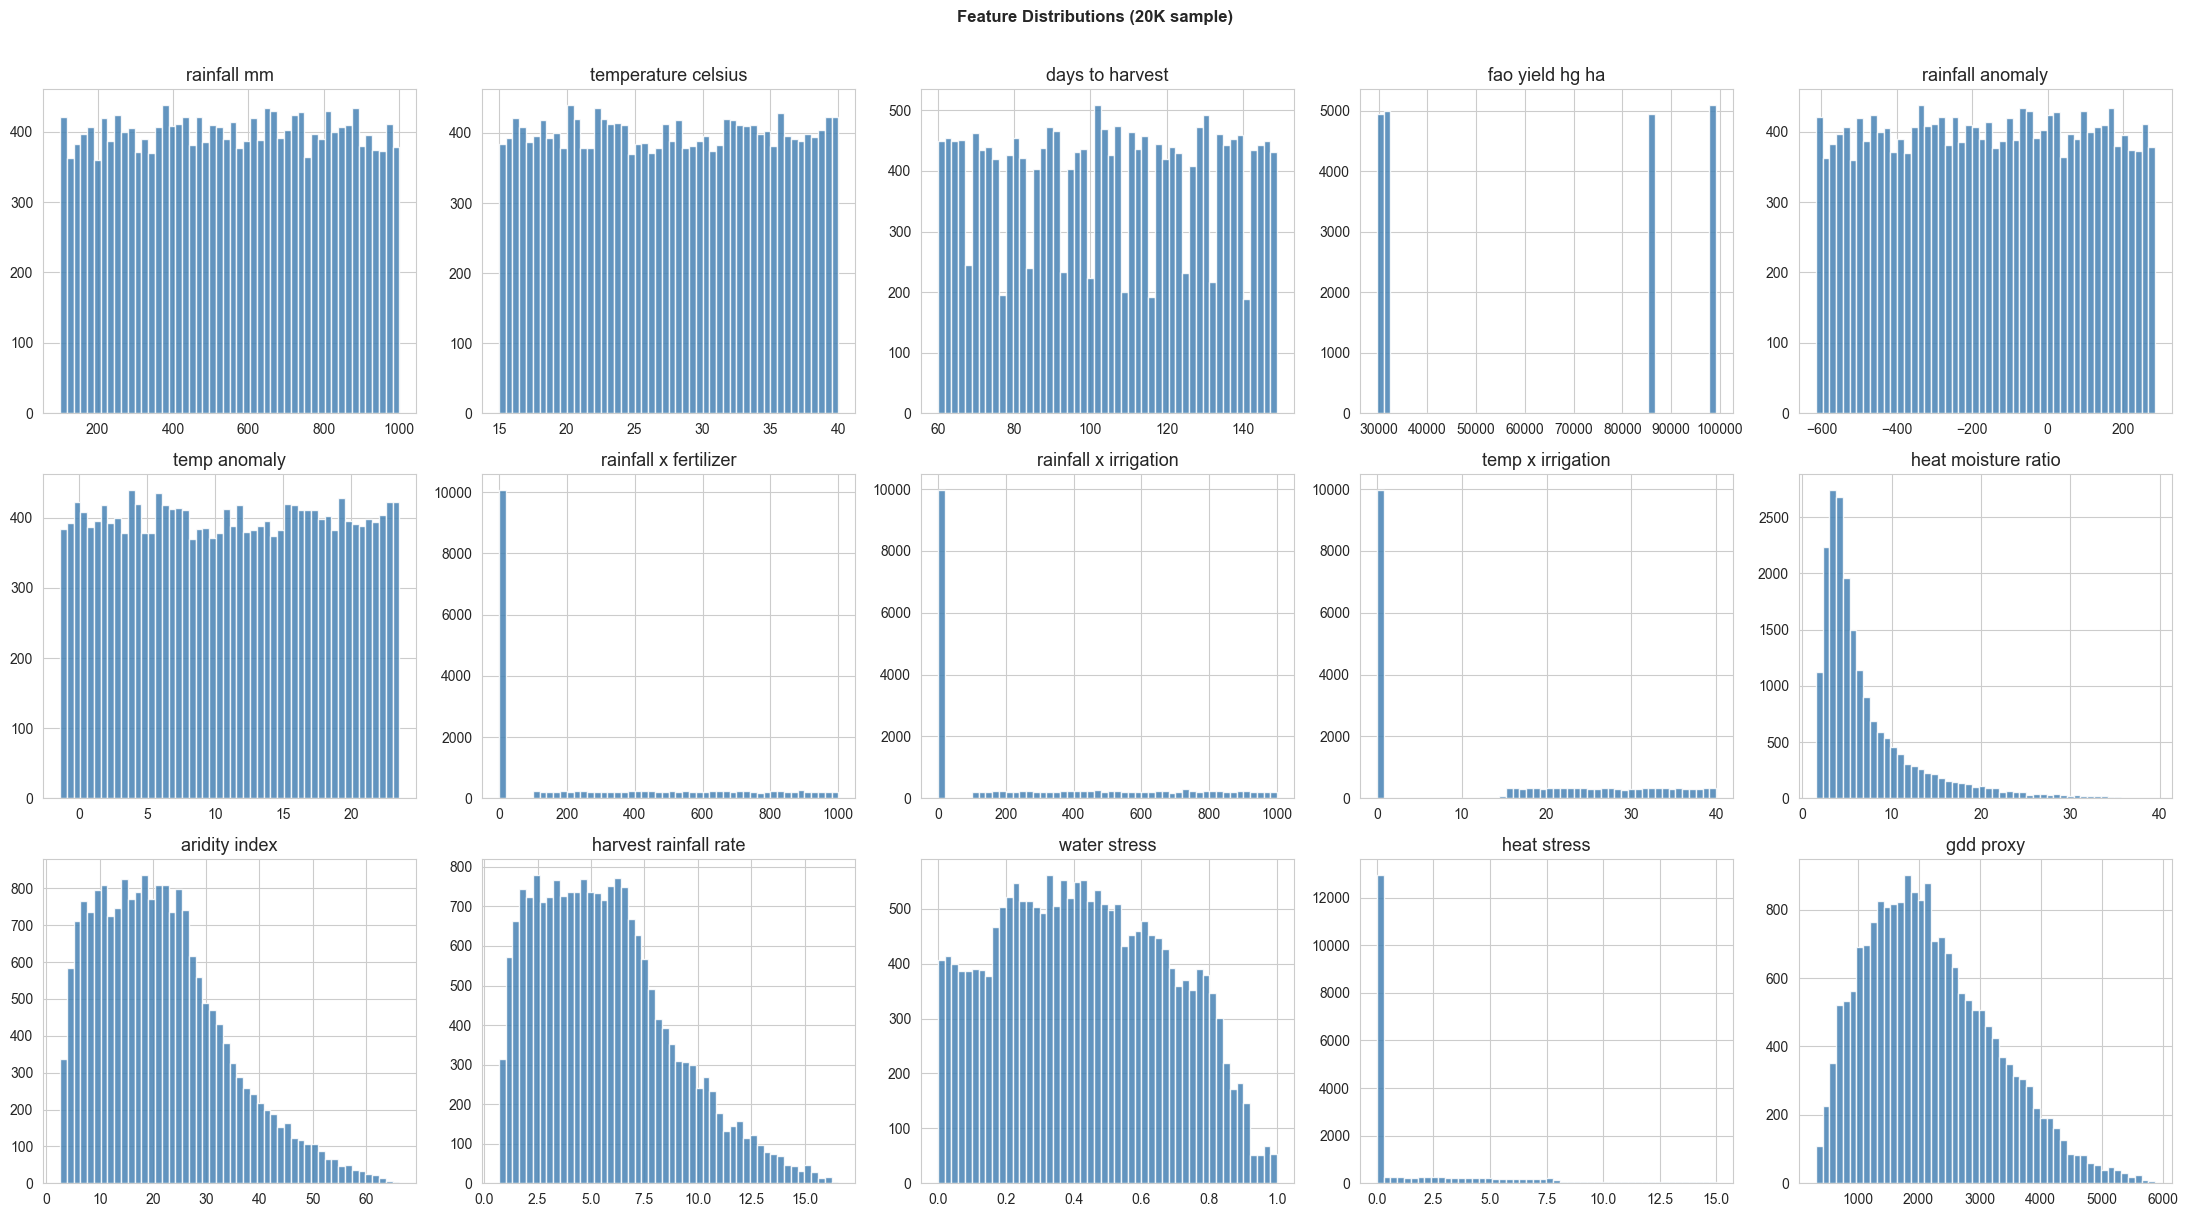

Saved → feat_01_distributions.png


In [3]:
# Continuous/numeric engineered features (excluding one-hots and binary)
numeric_feats = [
    'rainfall_mm', 'temperature_celsius', 'days_to_harvest',
    'fao_yield_hg_ha', 'rainfall_anomaly', 'temp_anomaly',
    'rainfall_x_fertilizer', 'rainfall_x_irrigation', 'temp_x_irrigation',
    'heat_moisture_ratio', 'aridity_index', 'harvest_rainfall_rate',
    'water_stress', 'heat_stress', 'gdd_proxy',
]

sample = feat.sample(20_000, random_state=42)

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_feats):
    ax.hist(sample[col], bins=50, color='steelblue', alpha=0.85, edgecolor='white')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')

# Hide unused axes
for ax in axes[len(numeric_feats):]:
    ax.set_visible(False)

plt.suptitle('Feature Distributions (20K sample)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/feat_01_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_01_distributions.png')

---
## 3. Correlation with Target (Pearson r)

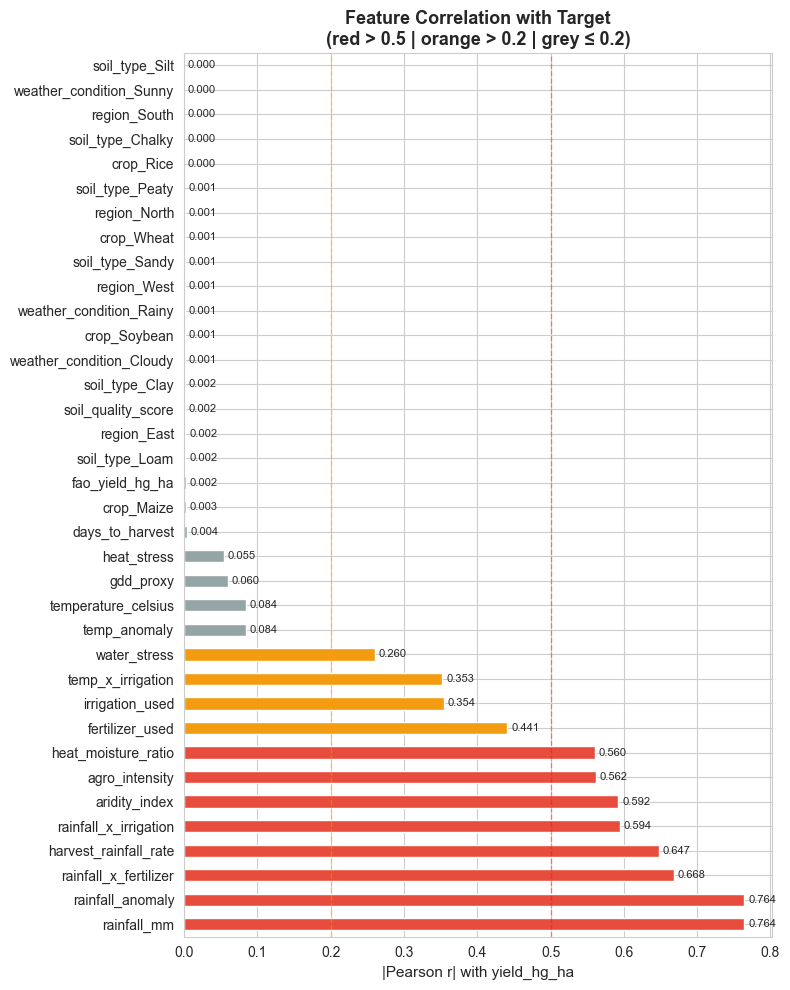

Saved → feat_02_correlations.png

Feature correlations with target:
rainfall_mm                 0.7644
rainfall_anomaly            0.7644
rainfall_x_fertilizer       0.6680
harvest_rainfall_rate       0.6474
rainfall_x_irrigation       0.5945
aridity_index               0.5925
agro_intensity              0.5620
heat_moisture_ratio         0.5602
fertilizer_used             0.4413
irrigation_used             0.3541
temp_x_irrigation           0.3525
water_stress                0.2599
temp_anomaly                0.0842
temperature_celsius         0.0842
gdd_proxy                   0.0595
heat_stress                 0.0548
days_to_harvest             0.0042
crop_Maize                  0.0028
fao_yield_hg_ha             0.0023
soil_type_Loam              0.0020
region_East                 0.0020
soil_quality_score          0.0017
soil_type_Clay              0.0017
weather_condition_Cloudy    0.0015
crop_Soybean                0.0014
weather_condition_Rainy     0.0013
region_West           

In [4]:
numeric_only = feat[feature_cols].select_dtypes(include='number')
corr = numeric_only.corrwith(feat[TARGET]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#e74c3c' if r > 0.5 else '#f39c12' if r > 0.2 else '#95a5a6'
          for r in corr.values]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('|Pearson r| with yield_hg_ha')
ax.set_title('Feature Correlation with Target\n(red > 0.5 | orange > 0.2 | grey ≤ 0.2)',
             fontweight='bold')
ax.axvline(0.5, color='red', ls='--', alpha=0.4, lw=1)
ax.axvline(0.2, color='orange', ls='--', alpha=0.4, lw=1)
for i, (name, val) in enumerate(corr.items()):
    ax.text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/feat_02_correlations.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_02_correlations.png')
print()
print('Feature correlations with target:')
print(corr.round(4).to_string())

---
## 4. Mutual Information Scores

Mutual Information captures **non-linear** relationships that Pearson r misses.

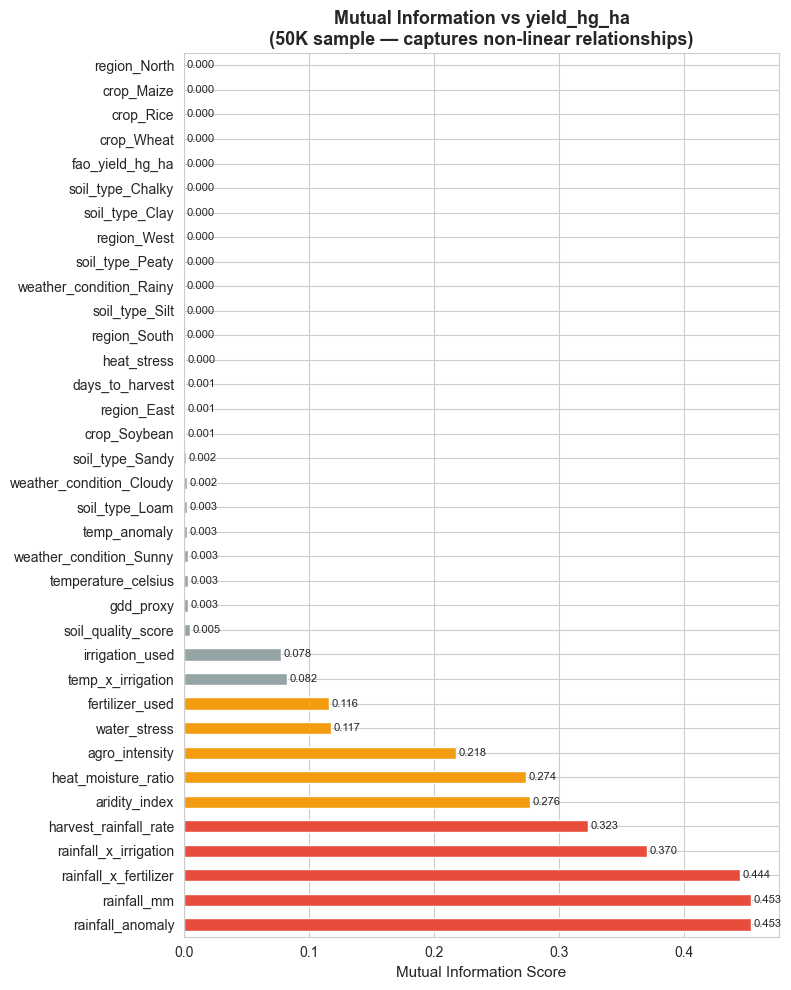

Saved → feat_03_mutual_info.png

Top 15 MI scores:
rainfall_anomaly         0.4530
rainfall_mm              0.4530
rainfall_x_fertilizer    0.4445
rainfall_x_irrigation    0.3699
harvest_rainfall_rate    0.3228
aridity_index            0.2764
heat_moisture_ratio      0.2737
agro_intensity           0.2178
water_stress             0.1173
fertilizer_used          0.1160
temp_x_irrigation        0.0820
irrigation_used          0.0777
soil_quality_score       0.0048
gdd_proxy                0.0031
temperature_celsius      0.0028


In [5]:
# Use a subsample for speed (MI is computationally intensive)
sub = feat.sample(50_000, random_state=42)
X_sub = sub[feature_cols].select_dtypes(include='number')
y_sub = sub[TARGET]

mi_scores = mutual_info_regression(X_sub, y_sub, random_state=42)
mi = pd.Series(mi_scores, index=X_sub.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors_mi = ['#e74c3c' if v > 0.3 else '#f39c12' if v > 0.1 else '#95a5a6'
             for v in mi.values]
mi.plot(kind='barh', ax=ax, color=colors_mi, edgecolor='white')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information vs yield_hg_ha\n(50K sample — captures non-linear relationships)',
             fontweight='bold')
for i, (name, val) in enumerate(mi.items()):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/feat_03_mutual_info.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_03_mutual_info.png')
print()
print('Top 15 MI scores:')
print(mi.head(15).round(4).to_string())

---
## 5. Random Forest Feature Importance (quick proxy)

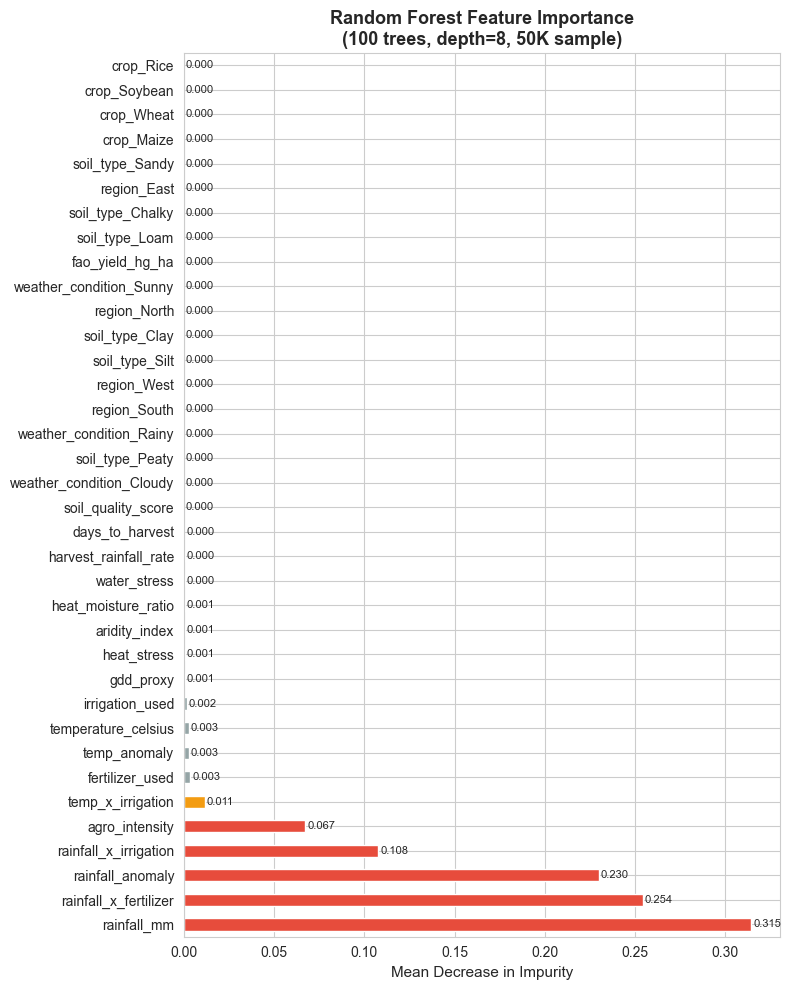

Saved → feat_04_rf_importance.png

Top 15 RF importances:
rainfall_mm              0.3146
rainfall_x_fertilizer    0.2544
rainfall_anomaly         0.2301
rainfall_x_irrigation    0.1077
agro_intensity           0.0673
temp_x_irrigation        0.0114
fertilizer_used          0.0035
temp_anomaly             0.0028
temperature_celsius      0.0027
irrigation_used          0.0017
gdd_proxy                0.0006
heat_stress              0.0006
aridity_index            0.0006
heat_moisture_ratio      0.0005
water_stress             0.0005

R² on training subset: 0.9174


In [6]:
# Fit a shallow RF on a 50K sample — impurity-based importance
X_rf = sub[feature_cols].select_dtypes(include='number')
y_rf = sub[TARGET]

rf = RandomForestRegressor(
    n_estimators=100, max_depth=8,
    random_state=42, n_jobs=-1
)
rf.fit(X_rf, y_rf)

importances = pd.Series(
    rf.feature_importances_, index=X_rf.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors_rf = ['#e74c3c' if v > 0.05 else '#f39c12' if v > 0.01 else '#95a5a6'
             for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors_rf, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Random Forest Feature Importance\n(100 trees, depth=8, 50K sample)',
             fontweight='bold')
for i, (name, val) in enumerate(importances.items()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/feat_04_rf_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_04_rf_importance.png')
print()
print('Top 15 RF importances:')
print(importances.head(15).round(4).to_string())
print(f'\nR² on training subset: {rf.score(X_rf, y_rf):.4f}')

---
## 6. Correlation Heatmap (numeric features)

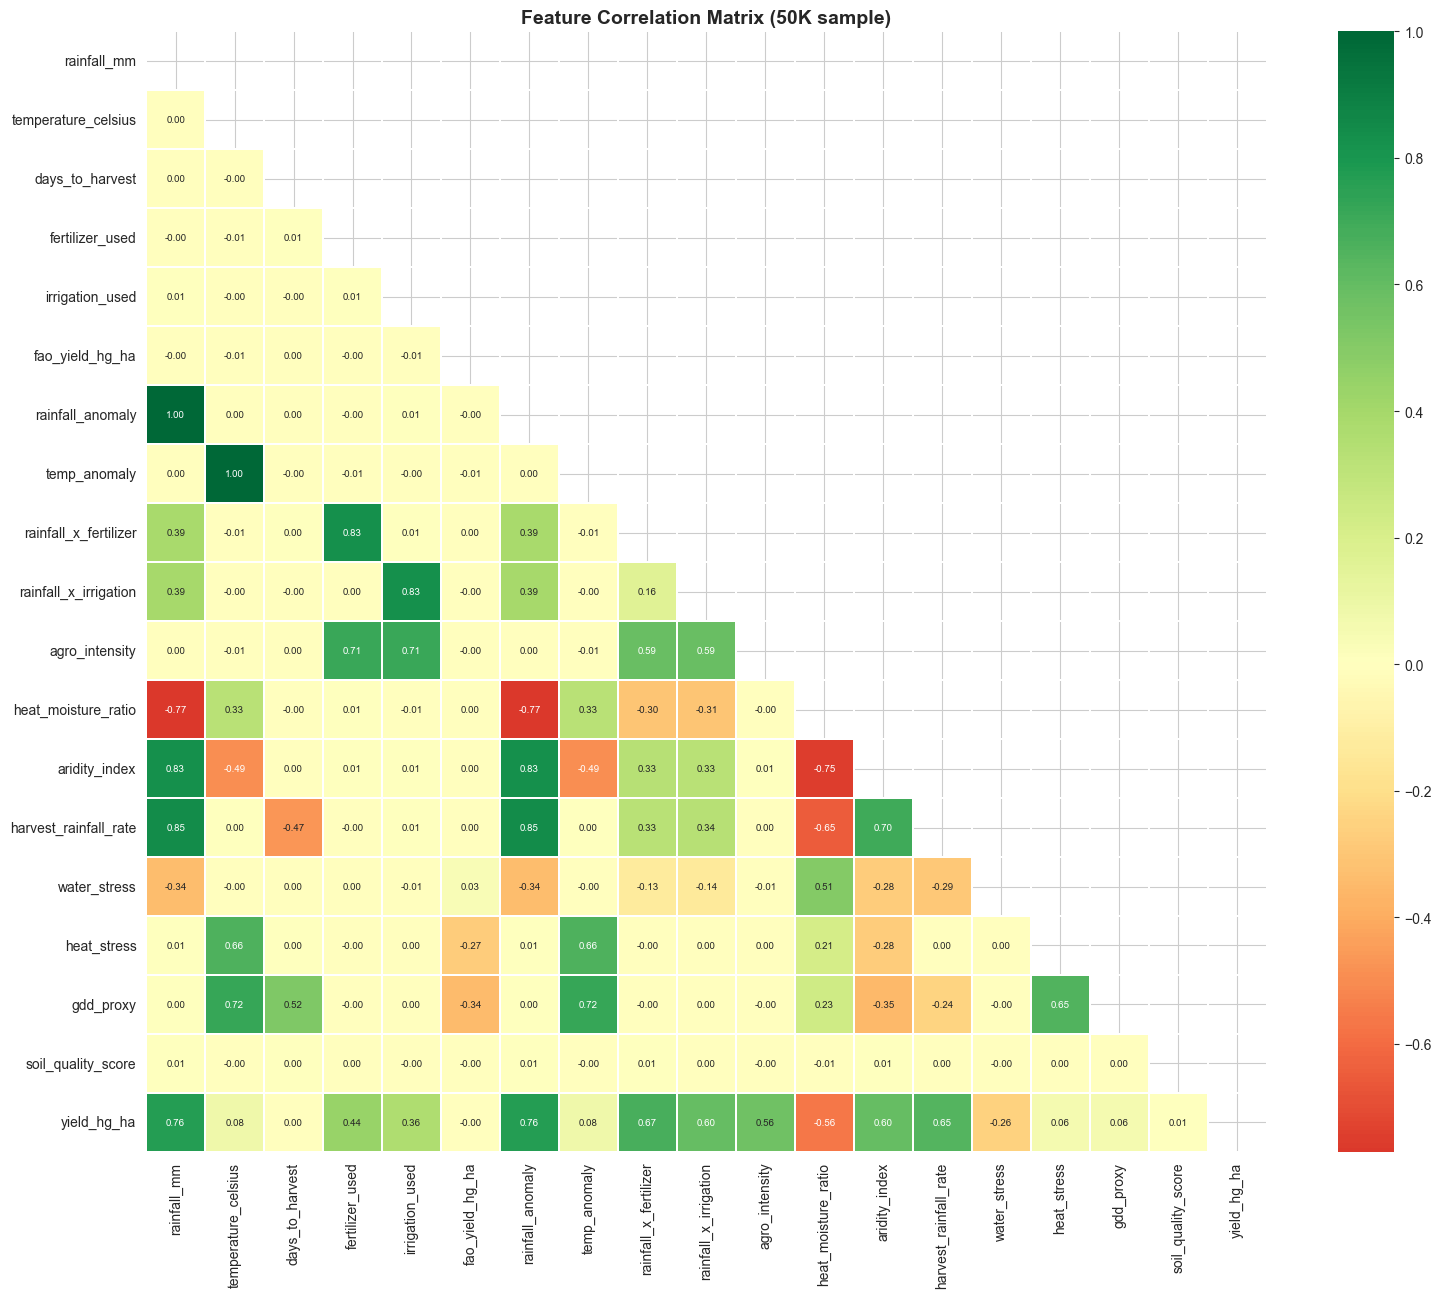

Saved → feat_05_heatmap.png


In [7]:
# Focus on non-one-hot numeric features
heatmap_cols = [
    'rainfall_mm', 'temperature_celsius', 'days_to_harvest',
    'fertilizer_used', 'irrigation_used', 'fao_yield_hg_ha',
    'rainfall_anomaly', 'temp_anomaly',
    'rainfall_x_fertilizer', 'rainfall_x_irrigation', 'agro_intensity',
    'heat_moisture_ratio', 'aridity_index', 'harvest_rainfall_rate',
    'water_stress', 'heat_stress', 'gdd_proxy',
    'soil_quality_score', TARGET
]

corr_matrix = feat[heatmap_cols].sample(50_000, random_state=42).corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.3, square=True, annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix (50K sample)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/feat_05_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_05_heatmap.png')

---
## 7. Domain Feature Analysis — Water Stress & Heat Stress by Crop

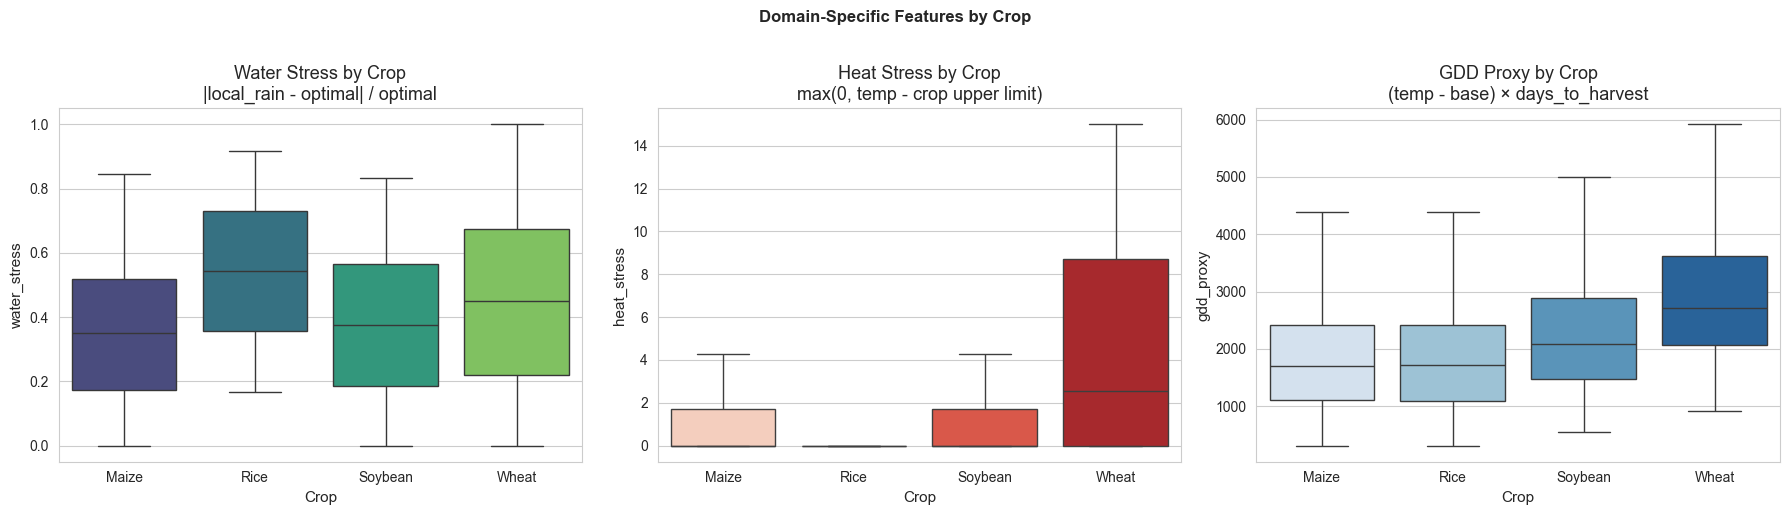

Saved → feat_06_domain_features.png


In [8]:
# Reconstruct crop labels from one-hot for visualisation
crop_cols = [c for c in feat.columns if c.startswith('crop_')]
feat_vis = feat.copy()
feat_vis['crop'] = feat[crop_cols].idxmax(axis=1).str.replace('crop_', '')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Water stress by crop
sns.boxplot(data=feat_vis.sample(30_000, random_state=42),
            x='crop', y='water_stress',
            order=['Maize','Rice','Soybean','Wheat'],
            palette='viridis', ax=axes[0], showfliers=False)
axes[0].set_title('Water Stress by Crop\n|local_rain - optimal| / optimal')
axes[0].set_xlabel('Crop')

# Heat stress by crop
sns.boxplot(data=feat_vis.sample(30_000, random_state=42),
            x='crop', y='heat_stress',
            order=['Maize','Rice','Soybean','Wheat'],
            palette='Reds', ax=axes[1], showfliers=False)
axes[1].set_title('Heat Stress by Crop\nmax(0, temp - crop upper limit)')
axes[1].set_xlabel('Crop')

# GDD proxy by crop
sns.boxplot(data=feat_vis.sample(30_000, random_state=42),
            x='crop', y='gdd_proxy',
            order=['Maize','Rice','Soybean','Wheat'],
            palette='Blues', ax=axes[2], showfliers=False)
axes[2].set_title('GDD Proxy by Crop\n(temp - base) × days_to_harvest')
axes[2].set_xlabel('Crop')

plt.suptitle('Domain-Specific Features by Crop', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/feat_06_domain_features.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_06_domain_features.png')

---
## 8. Scatter Plots — Top Features vs Target

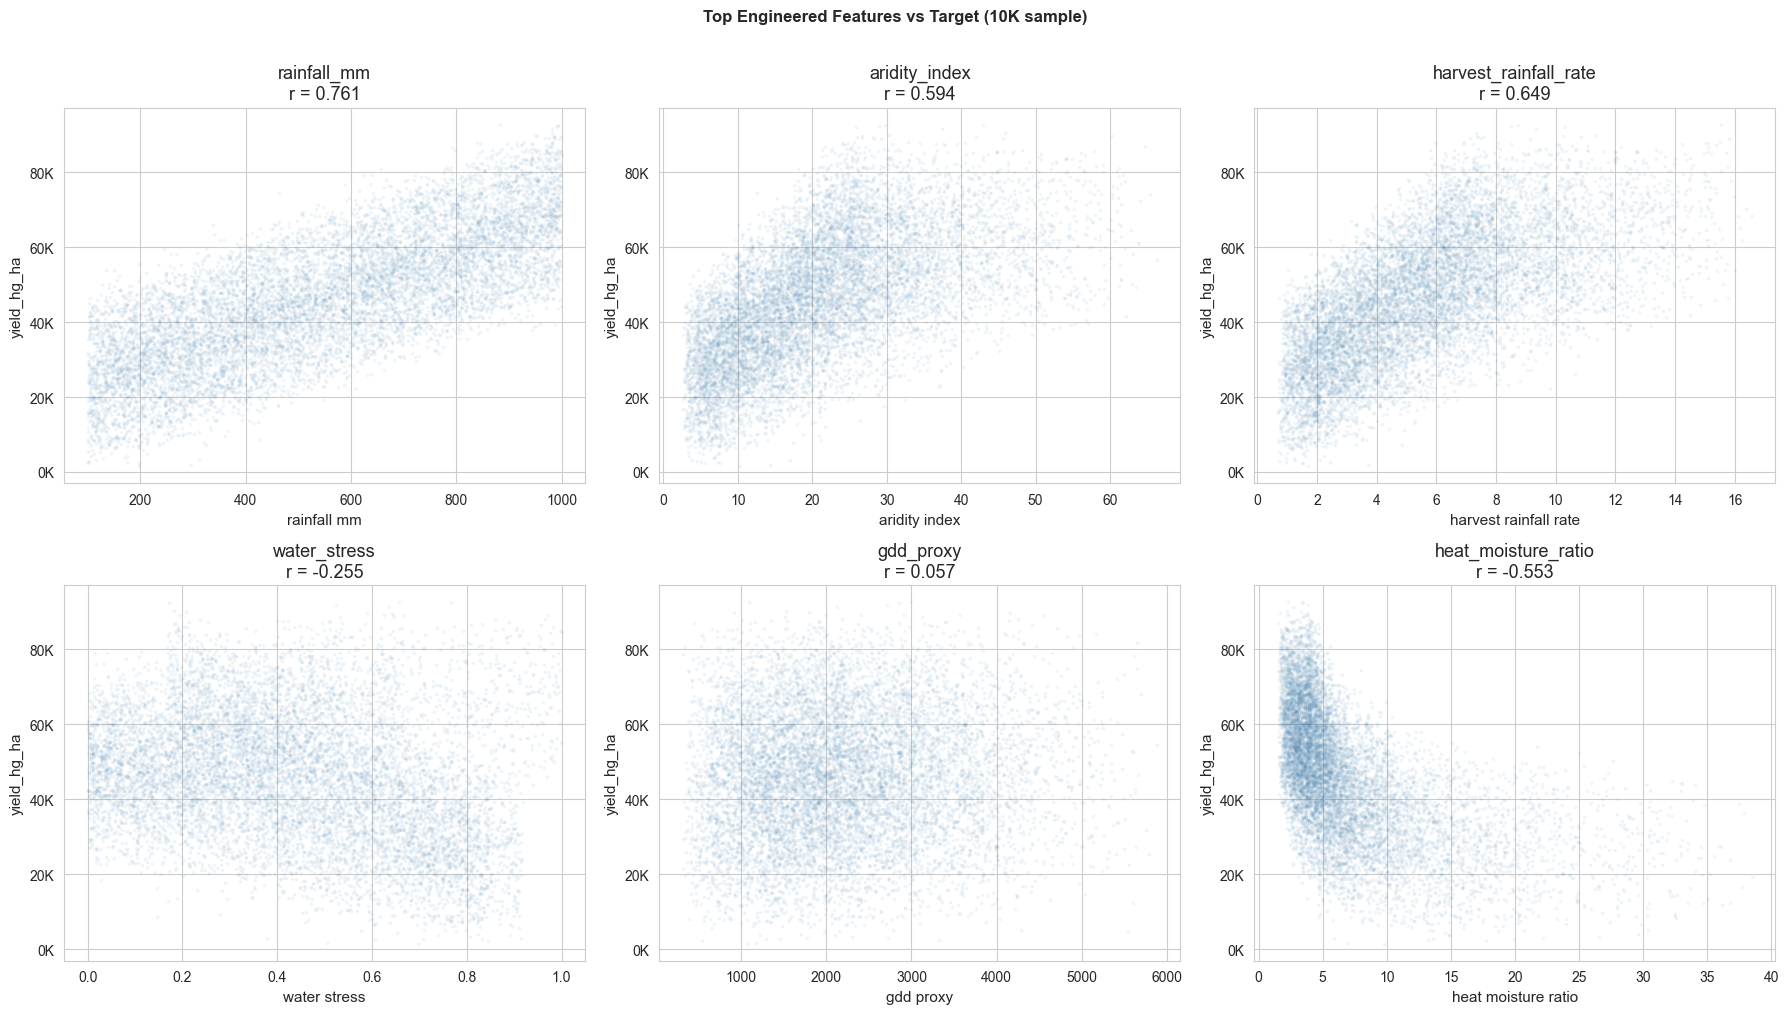

Saved → feat_07_scatter_top_features.png


In [9]:
top_feats = ['rainfall_mm', 'aridity_index', 'harvest_rainfall_rate',
             'water_stress', 'gdd_proxy', 'heat_moisture_ratio']

sample_s = feat.sample(10_000, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, top_feats):
    r = sample_s[col].corr(sample_s[TARGET])
    ax.scatter(sample_s[col], sample_s[TARGET],
               alpha=0.05, s=3, color='steelblue')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('yield_hg_ha')
    ax.set_title(f'{col}\nr = {r:.3f}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Top Engineered Features vs Target (10K sample)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/feat_07_scatter_top_features.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → feat_07_scatter_top_features.png')

---
## 9. Summary: Feature Ranking Table

In [10]:
numeric_cols_only = feat[feature_cols].select_dtypes(include='number').columns.tolist()

ranking = pd.DataFrame({
    '|Pearson r|': corr[numeric_cols_only],
    'Mutual Info':  mi[numeric_cols_only],
    'RF Importance': importances[numeric_cols_only],
})
ranking['Mean Rank'] = ranking.rank(ascending=False).mean(axis=1)
ranking = ranking.sort_values('Mean Rank')

print('Feature ranking (lower mean rank = more important):')
display(ranking.round(4))

Feature ranking (lower mean rank = more important):


,|Pearson r|,Mutual Info,RF Importance,Mean Rank
rainfall_mm,0.7644,0.4530,0.3146,1.3333
rainfall_anomaly,0.7644,0.4530,0.2301,2.0000
rainfall_x_fertilizer,0.6680,0.4445,0.2544,2.6667
rainfall_x_irrigation,0.5945,0.3699,0.1077,4.3333
agro_intensity,0.5620,0.2178,0.0673,6.6667
harvest_rainfall_rate,0.6474,0.3228,0.0004,8.3333
aridity_index,0.5925,0.2764,0.0006,8.3333
fertilizer_used,0.4413,0.1160,0.0035,8.6667
temp_x_irrigation,0.3525,0.0820,0.0114,9.3333
heat_moisture_ratio,0.5602,0.2737,0.0005,9.6667


---
## 10. Save Feature Dataset

In [11]:
feat.to_csv('../data/processed/features_dataset.csv', index=False)
print(f'Saved features_dataset.csv: {feat.shape}')
print(f'Features : {len(feature_cols)}')
print(f'Target   : {TARGET}')
print(f'Nulls    : {feat.isnull().sum().sum()}')
print()
print('=== Phase 3 Complete ===')
print('Feature groups:')
groups = {
    'Raw numeric (3)'    : ['rainfall_mm', 'temperature_celsius', 'days_to_harvest'],
    'Raw binary (2)'     : ['fertilizer_used', 'irrigation_used'],
    'FAO benchmark (1)'  : ['fao_yield_hg_ha'],
    'FAO anomalies (2)'  : ['rainfall_anomaly', 'temp_anomaly'],
    'Interactions (4)'   : ['rainfall_x_fertilizer', 'rainfall_x_irrigation', 'temp_x_irrigation', 'agro_intensity'],
    'Climate indices (3)': ['heat_moisture_ratio', 'aridity_index', 'harvest_rainfall_rate'],
    'Crop biology (3)'   : ['water_stress', 'heat_stress', 'gdd_proxy'],
    'Soil quality (1)'   : ['soil_quality_score'],
    'One-hot (17)'       : [c for c in feature_cols if any(c.startswith(p) for p in ['crop_','region_','soil_type_','weather_'])],
}
for group, cols in groups.items():
    print(f'  {group}: {cols}')

Saved features_dataset.csv: (666494, 37)
Features : 36
Target   : yield_hg_ha
Nulls    : 0

=== Phase 3 Complete ===
Feature groups:
  Raw numeric (3): ['rainfall_mm', 'temperature_celsius', 'days_to_harvest']
  Raw binary (2): ['fertilizer_used', 'irrigation_used']
  FAO benchmark (1): ['fao_yield_hg_ha']
  FAO anomalies (2): ['rainfall_anomaly', 'temp_anomaly']
  Interactions (4): ['rainfall_x_fertilizer', 'rainfall_x_irrigation', 'temp_x_irrigation', 'agro_intensity']
  Climate indices (3): ['heat_moisture_ratio', 'aridity_index', 'harvest_rainfall_rate']
  Crop biology (3): ['water_stress', 'heat_stress', 'gdd_proxy']
  Soil quality (1): ['soil_quality_score']
  One-hot (17): ['crop_Maize', 'crop_Rice', 'crop_Soybean', 'crop_Wheat', 'region_East', 'region_North', 'region_South', 'region_West', 'soil_type_Chalky', 'soil_type_Clay', 'soil_type_Loam', 'soil_type_Peaty', 'soil_type_Sandy', 'soil_type_Silt', 'weather_condition_Cloudy', 'weather_condition_Rainy', 'weather_condition_Sunny